# SynthACticBench O1, problem seed 53

Five SMAC seeds per policy, using the same setup as `02_leafs_seeds` with only the SynthACticBench problem seed changed from 52 to 53.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/leaf_policies/03_benchmark_seed")
OUTPUT_DIRECTORY = HERE / "smac_output"
POLICIES = ("fixed_leaf_1", "fixed_leaf_2", "fixed_leaf_3", "staged_leaf_3_2_1")
SEEDS = tuple(range(5))
CHECKPOINTS = (100, 200, 300, 400, 500)
LABELS = {
    "fixed_leaf_1": "fixed leaf = 1",
    "fixed_leaf_2": "fixed leaf = 2",
    "fixed_leaf_3": "fixed leaf = 3",
    "staged_leaf_3_2_1": "staged 3 → 2 → 1",
}

In [2]:
def load_results(policy):
    by_seed = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == 500:
            if seed not in by_seed or path.stat().st_mtime > by_seed[seed][0]:
                by_seed[seed] = (path.stat().st_mtime, result)
    missing = sorted(set(SEEDS) - set(by_seed))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}, seeds={missing}")
    return {seed: by_seed[seed][1] for seed in SEEDS}


results = {policy: load_results(policy) for policy in POLICIES}
assert all(
    result["problem_seed"] == 53
    for runs in results.values()
    for result in runs.values()
)
print(f"Loaded {sum(len(runs) for runs in results.values())}/20 seed-53 trajectories.")

Loaded 20/20 seed-53 trajectories.


In [3]:
# Verify paired settings and the staged/fixed-3 prefix for every seed.
comparison_fields = (
    "problem",
    "problem_seed",
    "instance_seed",
    "pythonhashseed",
    "n_instances",
    "instance_map",
    "n_trials",
)
reference = results["fixed_leaf_3"][0]
for policy, runs in results.items():
    for seed, result in runs.items():
        for field in comparison_fields:
            assert result[field] == reference[field], (policy, seed, field)
        assert result["smac_seed"] == seed
for seed in SEEDS:
    staged = results["staged_leaf_3_2_1"][seed]
    fixed_three = results["fixed_leaf_3"][seed]
    assert staged["objective_value"][:150] == fixed_three["objective_value"][:150], seed
print("All paired-run checks passed.")

All paired-run checks passed.


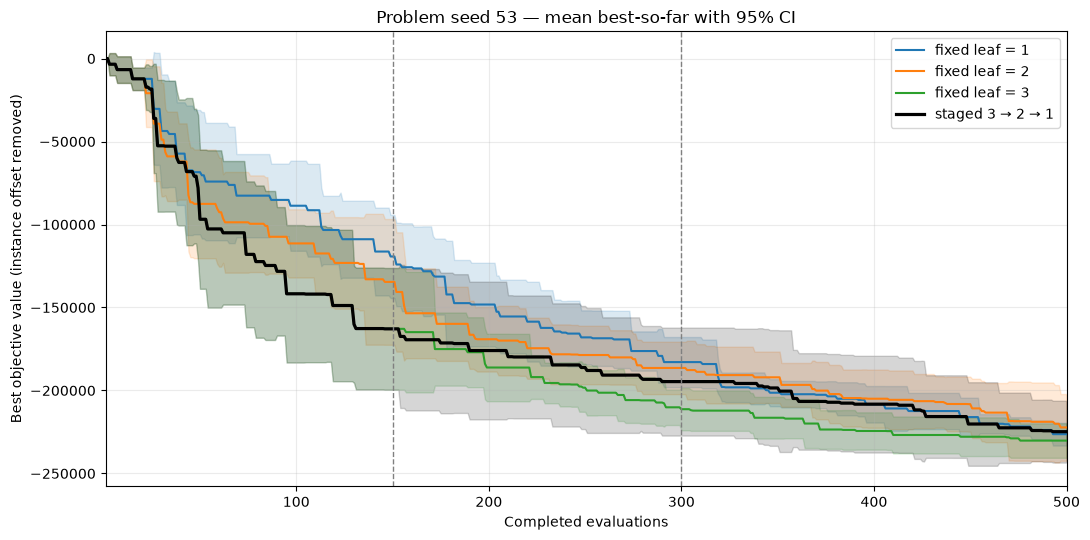

In [4]:
rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        rows.extend(
            {"policy": policy, "smac_seed": seed, "iteration": i, "best_so_far": best}
            for i, best in zip(result["iteration"], result["best_so_far"])
        )
trajectories = pd.DataFrame(rows)
summary = (
    trajectories.groupby(["policy", "iteration"])["best_so_far"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(11, 5.5))
for policy in POLICIES:
    data = summary[summary["policy"] == policy]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    style = {"color": "black", "linewidth": 2.3} if policy == "staged_leaf_3_2_1" else {}
    line = ax.plot(x, mean, label=LABELS[policy], **style)[0]
    ax.fill_between(x, mean - ci, mean + ci, color=line.get_color(), alpha=0.16)
ax.axvline(150, color="grey", linestyle="--", linewidth=1)
ax.axvline(300, color="grey", linestyle="--", linewidth=1)
ax.set(title="Problem seed 53 — mean best-so-far with 95% CI", xlabel="Completed evaluations", ylabel="Best objective value (instance offset removed)", xlim=(1, 500))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

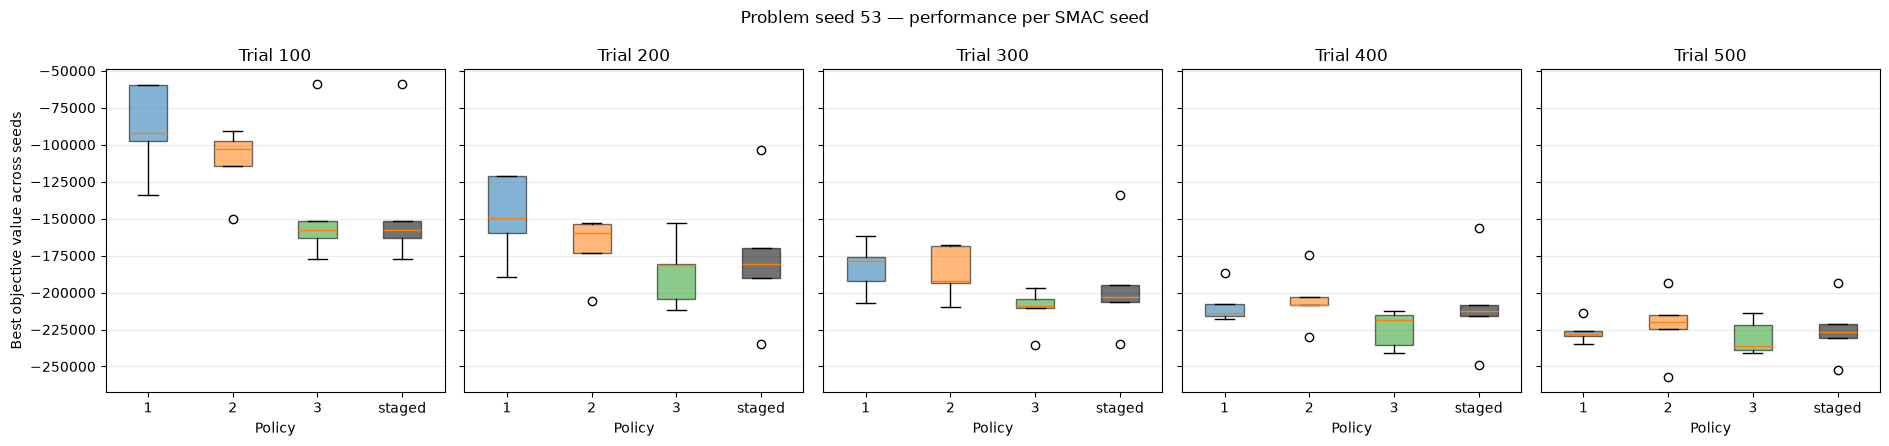

In [5]:
fig, axes = plt.subplots(1, len(CHECKPOINTS), figsize=(19, 4.5), sharey=True)
for ax, checkpoint in zip(axes, CHECKPOINTS):
    values = [
        [results[policy][seed]["best_so_far"][checkpoint - 1] for seed in SEEDS]
        for policy in POLICIES
    ]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=["1", "2", "3", "staged"])
    for box, color in zip(boxes["boxes"], ("C0", "C1", "C2", "black")):
        box.set(facecolor=color, alpha=0.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.set_xlabel("Policy")
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Best objective value across seeds")
fig.suptitle("Problem seed 53 — performance per SMAC seed")
plt.tight_layout()
plt.show()

In [6]:
(
    trajectories[trajectories["iteration"].isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_so_far"]
    .agg(["mean", "std", "min", "median", "max"])
)

mean           std            min  \
iteration policy                                                          
100       fixed_leaf_1       -88683.916620  30982.458342 -134275.417234   
          fixed_leaf_2      -111394.412544  23449.120374 -150376.499949   
          fixed_leaf_3      -141748.482469  47245.691990 -177147.521004   
          staged_leaf_3_2_1 -141748.482469  47245.691990 -177147.521004   
200       fixed_leaf_1      -148210.595400  28690.622983 -189386.704745   
          fixed_leaf_2      -169134.880410  22205.680590 -206006.857754   
          fixed_leaf_3      -186159.670246  23198.736946 -212111.412008   
          staged_leaf_3_2_1 -175944.246214  47331.124041 -235003.981569   
300       fixed_leaf_1      -182900.060151  17216.065435 -206938.711403   
          fixed_leaf_2      -186435.893753  18004.624502 -210065.277144   
          fixed_leaf_3      -211278.688411  14513.538051 -235547.405389   
          staged_leaf_3_2_1 -194650.196496  37112.717504 -235061.696530   
400       fixed_leaf_1      -208324.415796  12560.512288 -217807.916151   
          fixed_leaf_2      -204965.076436  19966.994599 -230169.044506   
          fixed_leaf_3      -224405.131488  12811.185357 -240565.575608   
          staged_leaf_3_2_1 -208251.778227  33255.376518 -248749.191503   
500       fixed_leaf_1      -226326.939070   7826.021503 -234464.879420   
          fixed_leaf_2      -222265.679965  22940.683315 -257360.911370   
          fixed_leaf_3      -230205.557678  11830.947509 -240945.677225   
          staged_leaf_3_2_1 -224827.645671  21257.749914 -252527.583740   

                                    median            max  
iteration policy                                           
100       fixed_leaf_1       -91766.693821  -59783.005918  
          fixed_leaf_2      -103188.315040  -90982.706843  
          fixed_leaf_3      -157889.326320  -58924.221077  
          staged_leaf_3_2_1 -157889.326320  -58924.221077  
200       fixed_leaf_1      -149313.906195 -121004.749016  
          fixed_leaf_2      -159937.163925 -152821.247790  
          fixed_leaf_3      -181166.383299 -152941.721547  
          staged_leaf_3_2_1 -180979.244173 -103709.718481  
300       fixed_leaf_1      -178501.683489 -161535.679890  
          fixed_leaf_2      -191960.724812 -167798.388138  
          fixed_leaf_3      -208931.900047 -197019.932714  
          staged_leaf_3_2_1 -203052.058709 -134102.778582  
400       fixed_leaf_1      -213549.367806 -186950.260799  
          fixed_leaf_2      -208520.991314 -174477.838538  
          fixed_leaf_3      -218871.487298 -212173.717934  
          staged_leaf_3_2_1 -212279.444901 -156162.889741  
500       fixed_leaf_1      -228262.056209 -213549.367806  
          fixed_leaf_2      -220124.223263 -193765.018153  
          fixed_leaf_3      -235822.166775 -213877.607105  
          staged_leaf_3_2_1 -226427.751040 -193419.412167